# Exercise 4.13
***

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from ISLP import load_data

## a)
***

In [141]:
#Loading data
Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [142]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [143]:
#Correlation matrix
corr = Weekly.drop(columns = 'Direction').corr()
print(corr.round(2))

        Year  Lag1  Lag2  Lag3  Lag4  Lag5  Volume  Today
Year    1.00 -0.03 -0.03 -0.03 -0.03 -0.03    0.84  -0.03
Lag1   -0.03  1.00 -0.07  0.06 -0.07 -0.01   -0.06  -0.08
Lag2   -0.03 -0.07  1.00 -0.08  0.06 -0.07   -0.09   0.06
Lag3   -0.03  0.06 -0.08  1.00 -0.08  0.06   -0.07  -0.07
Lag4   -0.03 -0.07  0.06 -0.08  1.00 -0.08   -0.06  -0.01
Lag5   -0.03 -0.01 -0.07  0.06 -0.08  1.00   -0.06   0.01
Volume  0.84 -0.06 -0.09 -0.07 -0.06 -0.06    1.00  -0.03
Today  -0.03 -0.08  0.06 -0.07 -0.01  0.01   -0.03   1.00


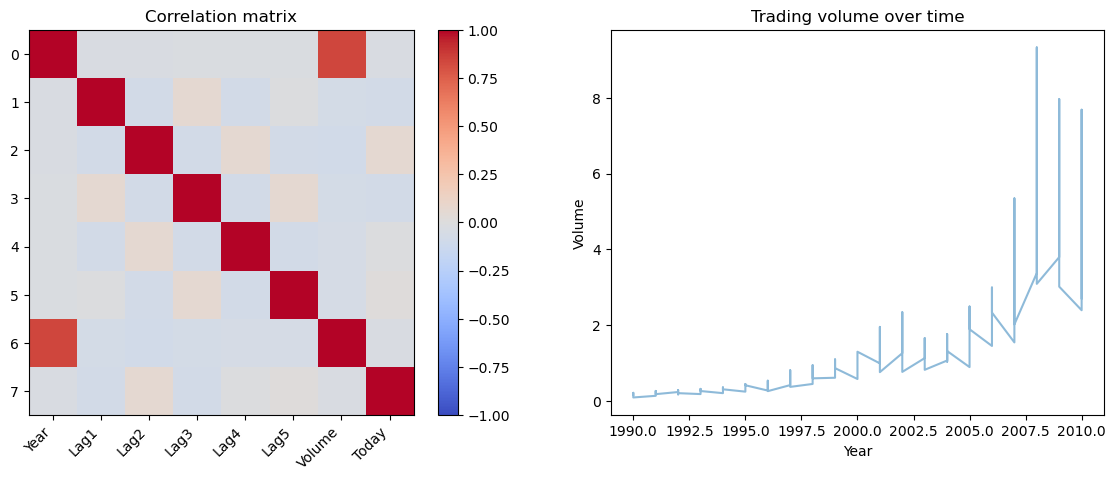

In [144]:
#Plots
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

#Heatmap of correlations
im = ax[0].imshow(corr, cmap = 'coolwarm', vmin = -1, vmax = 1)

ax[0].set_xticks(range(len(corr.columns)))
ax[0].set_yticks(range(len(corr.columns)))
ax[0].set_xticklabels(corr.columns, rotation = 45, ha = 'right')
ax[0].set_xticklabels(corr.columns)
ax[0].set_title('Correlation matrix')
plt.colorbar(im, ax = ax[0])

#Volume over time
ax[1].plot(Weekly['Year'], Weekly['Volume'], alpha = 0.5)
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Volume')
ax[1].set_title('Trading volume over time')

plt.tight_layout
plt.show()

## b)
***

In [145]:
#Converting Direction to binary to allow for numeric regression
Weekly['Direction_binary'] = (Weekly['Direction'] == 'Up').astype(int)

In [146]:
#Logistic regression model
logistic_model = smf.logit('Direction_binary ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume', data = Weekly).fit()
print(logistic_model.summary()) 

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:       Direction_binary   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                0.006580
Time:                        17:43:13   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

## c)
***

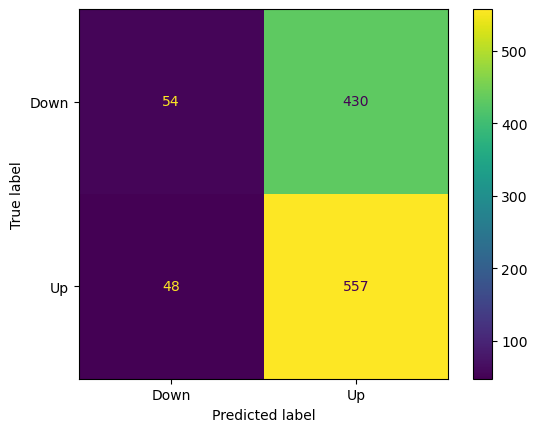

Share of correct: 0.5611


In [147]:
#Confusion matrix
pred_probs = logistic_model.predict()
pred_classes = (pred_probs >= 0.5).astype(int)

cm = confusion_matrix(Weekly['Direction_binary'], pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Down', 'Up'])
disp.plot()
plt.show()

accuracy = (pred_classes == Weekly['Direction_binary']).mean()
print(f'Share of correct: {accuracy:.4f}')

### Interpretation

As the market is more up than down (in the dataset), the model has learned to say Up in almost any case. A accuracy of 56% is almost as good as simply guessing, meaning the model does not provide any meaningful value. 

## d)
***

In [148]:
#Splitting data
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

In [149]:
#Fit model with training data
logistic_model2 = smf.logit('Direction_binary ~ Lag2', data = train).fit()

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4


In [150]:
#Predicting on test data
pred_probs2 = logistic_model2.predict(test)
pred_classes2 = (pred_probs2 >= 0.5).astype(int)

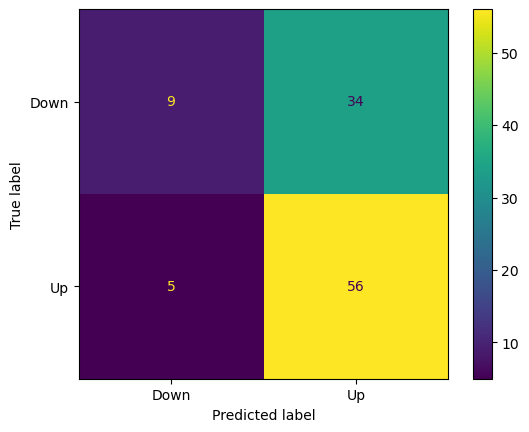

Share of accurate predictions: 62.50%
Improved accuracy: 11.40 %


In [151]:
#Confusion matrix
cm2 = confusion_matrix(test['Direction_binary'], pred_classes2)
disp2 = ConfusionMatrixDisplay(confusion_matrix = cm2, display_labels = ['Down', 'Up'])
disp2.plot()
plt.show()

accuracy2 = (pred_classes2 == test['Direction_binary']).mean()
print(f"Share of accurate predictions: {accuracy2 * 100:.2f}%")

improved_acc = (accuracy2 / accuracy - 1) * 100
print(f"Improved accuracy: {improved_acc:.2f} %")

### Interpretation

We see that only `Lag2` as predictor and using unseen test data improves accuracy by 11.4%. The model learned noise rather than true pattern in the training data, overfitting the first model.

## e)
***

In [152]:
#Fit LDA on training data
lda = LinearDiscriminantAnalysis()
lda.fit(train[['Lag2']], train['Direction_binary'])

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [153]:
#Predict on test data
pred_classes_lda = lda.predict(test[['Lag2']])

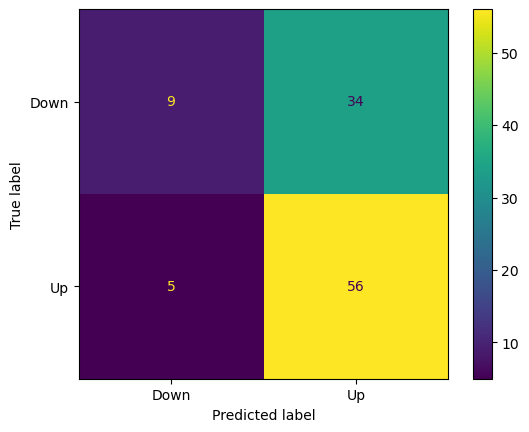

Share of accurate predictions: 0.6250
Improved accuracy: 11.40 %


In [154]:
#Confusion matrix
cm_lda = confusion_matrix(test['Direction_binary'], pred_classes_lda)
disp_lda = ConfusionMatrixDisplay(confusion_matrix = cm_lda, display_labels = ['Down', 'Up'])

disp_lda.plot()
plt.show()

accuracy_lda = (pred_classes_lda == test['Direction_binary']).mean()
print(f"Share of accurate predictions: {accuracy_lda:.4f}")

improved_acc_lda = (accuracy_lda / accuracy - 1) * 100
print(f"Improved accuracy: {improved_acc_lda:.2f} %")

## f)
***

In [155]:
#Fit training data on QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(train[['Lag2']], train['Direction_binary'])

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [156]:
#Predict on test data
pred_classes_qda = qda.predict(test[['Lag2']])

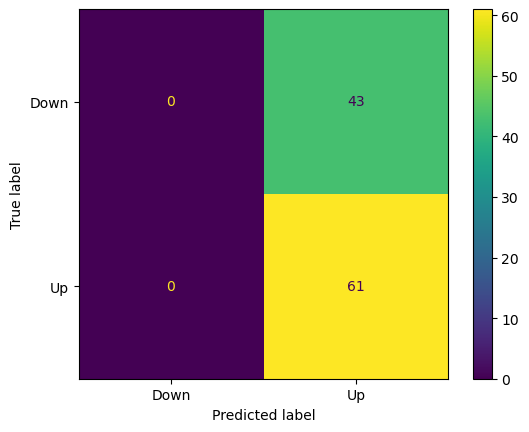

Share of accurate predictions: 0.5865
Improved accuracy: 4.54 %


In [157]:
#Confusion matrix
cm_qda = confusion_matrix(test['Direction_binary'], pred_classes_qda)
disp_qda = ConfusionMatrixDisplay(confusion_matrix = cm_qda, display_labels = ['Down', 'Up'])
disp_qda.plot()
plt.show()

accuracy_qda = (pred_classes_qda == test['Direction_binary']).mean()
print(f"Share of accurate predictions: {accuracy_qda:.4f}")

improved_acc_qda = (accuracy_qda / accuracy - 1) * 100
print(f"Improved accuracy: {improved_acc_qda:.2f} %")

## g)
***

In [158]:
#Fit training data on KNN with K = 1
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(train[['Lag2']], train['Direction_binary'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [159]:
#Predict on test data
pred_classes_knn = knn.predict(test[['Lag2']])

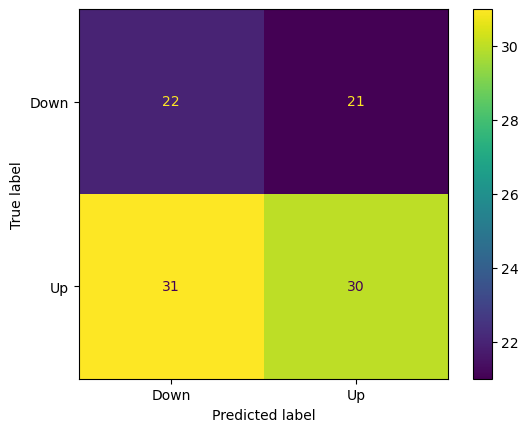

Share of accurate predictions: 0.50
Decreased accuracy: -10.88 %


In [160]:
#Confusion matrix
cm_knn = confusion_matrix(test['Direction_binary'], pred_classes_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix = cm_knn, display_labels = ['Down', 'Up'])
disp_knn.plot()
plt.show()

accuracy_knn = (pred_classes_knn == test['Direction_binary']).mean()
print(f"Share of accurate predictions: {accuracy_knn:.2f}")

improved_acc_knn = (accuracy_knn / accuracy - 1) * 100
print(f"Decreased accuracy: {improved_acc_knn:.2f} %")

## h)
***

In [162]:
#Fit Naive Bayes on training data
nb = GaussianNB()
nb.fit(train[['Lag2']], train['Direction_binary'])

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [163]:
#Predict on test data
pred_classes_nb = nb.predict(test[['Lag2']])

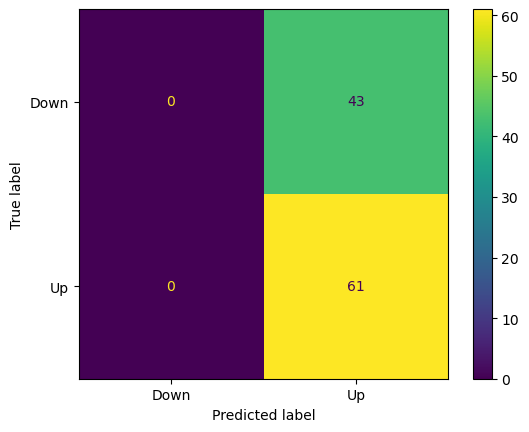

Share of accurate predictions: 0.59
Decreased accuracy: 4.54 %


In [166]:
#Confusion matrix
cm_nb = confusion_matrix(test['Direction_binary'], pred_classes_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix = cm_nb, display_labels = ['Down', 'Up'])
disp_nb.plot()
plt.show()

accuracy_nb = (pred_classes_nb == test['Direction_binary']).mean()
print(f"Share of accurate predictions: {accuracy_nb:.2f}")

improved_acc_nb = (accuracy_nb / accuracy - 1) * 100
print(f"Decreased accuracy: {improved_acc_nb:.2f} %")

## i)
***

### Interpretation

Logistic Regression and LDA both achieve the highest accuracy of 62.50%
on the test set, making them the best performing methods on this data.

QDA (58.65%) and Naive Bayes (59.00%) perform similarly, slightly worse
than Logistic Regression and LDA.

KNN with K=1 performs worst at 50.00%, essentially random guessing,
due to severe overfitting with K=1.

Overall, Logistic Regression and LDA are the best methods for this
dataset, likely because the true decision boundary is approximately
linear, which both methods assume.
